In [2]:
import numpy as np
import sys
print(sys.executable)
import rebound
import astropy.constants as const
import astropy.units as u
import matplotlib.pyplot as plt
from plotting_params import use_my_style
import glob
import netCDF4
from matplotlib.lines import Line2D
use_my_style()

/data/ally/my_env/bin/python


# Method 1 - getting min peris

## 1) Calculate saturated water vapor pressure

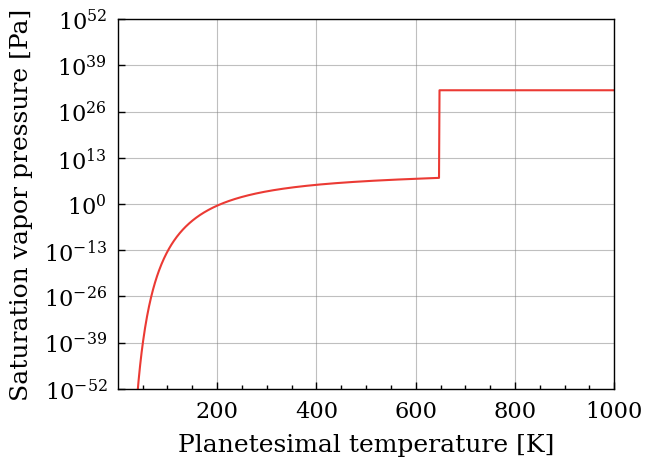

1.3070240132842796 Pa


In [3]:
def P_sat_vap(T_pl):

    Pc =22.065e6 * u.Pa
    Tc = 647.096 #Kelvin

    T_pl = np.asarray(T_pl, dtype=float)
    P_sat = np.full_like(T_pl, 1e32, dtype=float)
    mask = T_pl < Tc
    T_pl_valid = T_pl[mask]

    theta = T_pl_valid / Tc
    tau = 1 - theta
    a1, a2, a3, a4, a5, a6 = -7.85951783, 1.84408259, -11.7866497, 22.6807411, -15.9618719, 1.80122502
    log_p_over_pc = Tc/T_pl_valid * (a1*tau + a2*tau**1.5 + a3*tau**3 + a4*tau**3.5 + a5*tau**4 + a6*tau**7.5)

    P_sat[mask] = np.exp(log_p_over_pc) * Pc
    
    return P_sat*u.Pa

Ts = np.linspace(1, 1000, 1000)
plt.plot(Ts, P_sat_vap(Ts))
plt.yscale('log')
plt.ylim(1e-52, 1e52)
plt.xlabel('Planetesimal temperature [K]')
plt.ylabel('Saturation vapor pressure [Pa]')
plt.grid()
plt.show()

print(P_sat_vap(210))

## 2) Extract min peri from simulations

### function for doing it for 1 file

In [4]:
files_w_gas_3_pl = glob.glob(f'core_outputs_yr2/gas_drag/*3_pl_single_particle_2.nc')
files_w_gas_2_pl = glob.glob(f'core_outputs_yr2/gas_drag/*2_pl_single_particle_2.nc')
print(len(files_w_gas_3_pl))

def get_min_peri(filename):

    min_peri_list = []
    final_time = []
    a_list = []
    inc_list = []
    filecount = 0

    with netCDF4.Dataset(filename, 'r') as ncfile:

        test_particles = ncfile['test_particles'][:]
        test_particles = test_particles.filled(np.nan)
        massive_bodies = ncfile['massive_bodies'][:]
        tf = massive_bodies[-1][0][0]/5
        ple, pla = massive_bodies[:, :, 4], massive_bodies[:, :, 5] 
        
        apo_dist_b = pla[:,1] * (1 + ple[:,1]) 
        peri_dist_c = pla[:,2] * (1 - ple[:,2]) 
        c1 = np.all(ple < 1)
        c2 = np.all(apo_dist_b < 0.99*peri_dist_c)
        
        if c1 and c2:
            filecount += 1

            r = np.sqrt(test_particles[:, 1]**2 + test_particles[:, 2]**2 + test_particles[:, 3]**2)    

            a = test_particles[:, 5]
            ecc = test_particles[:,4]
            peris = a * (1 - ecc)
            inc = test_particles[:, 6]

                #ignore peris inside truncation radius
            perimask = ((r < 8) &
                        (peris > (3.4*1.26*const.R_sun.to(u.au).value)) &
                        (~np.isnan(peris)))

            if np.any(perimask):
                allowed_peris = peris[perimask]

                idx = np.argmin(allowed_peris)   

                min_peri = allowed_peris[idx]
                min_a = a[perimask][idx]
                min_inc = inc[perimask][idx]

                min_peri_list.append(min_peri)
                a_list.append(min_a)
                inc_list.append(min_inc)
                final_time.append(tf)

                return min_peri_list, a_list, inc_list, final_time, filecount 
            else:
                return None


1180


### function for combining all:

In [5]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def combine_all_particles(filenames):

    min_peri_list = []
    final_times = []
    a_list = []
    inc_list = []
    filecount_total = 0

    with ProcessPoolExecutor(max_workers=50) as executor:


        results = list(tqdm(
            executor.map(get_min_peri, filenames),
            total=len(filenames),
            desc=f"processing"
        ))

    results = [r for r in results if r is not None]


    for min_peri, a, inc, tfinal, filecount in results:
        min_peri_list.append(min_peri)
        final_times.append(tfinal)
        a_list.append(a)
        inc_list.append(inc)
        filecount_total += filecount

    return min_peri_list, a_list, inc_list, final_times, filecount_total

In [7]:
all_particles_gas_2_pl = combine_all_particles(files_w_gas_2_pl[:])
all_particles_gas_3_pl = combine_all_particles(files_w_gas_3_pl[:])

processing: 100%|██████████| 1180/1180 [00:28<00:00, 40.89it/s]


### format nicely

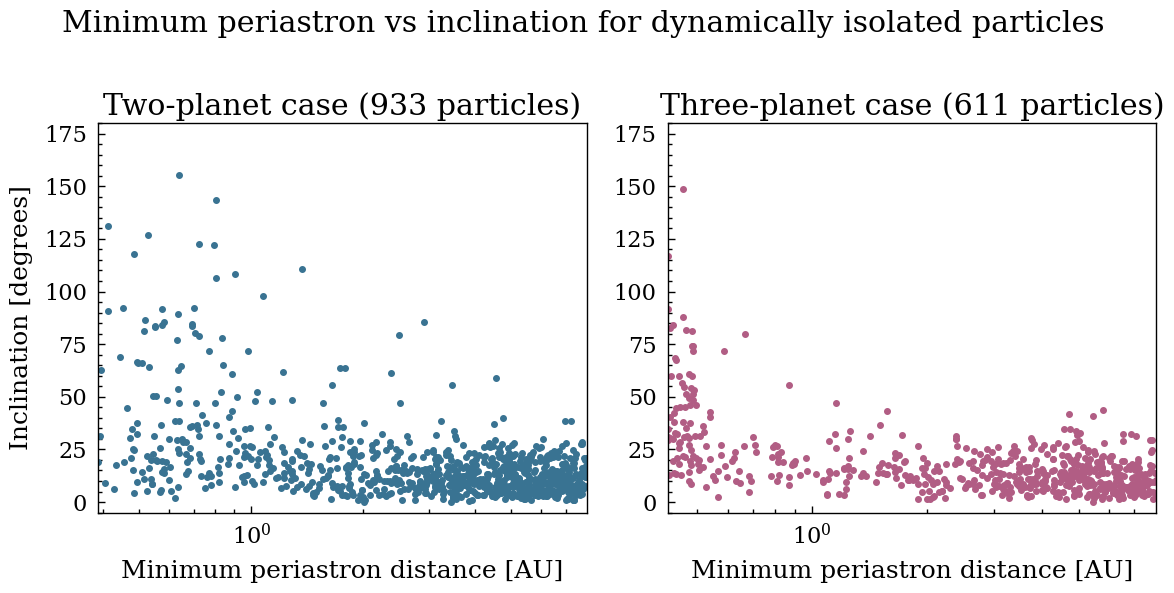

In [8]:
def plot_min_peri_vs_inc(all_particles_gas2, all_particles_gas3):
    all_peris_2 = np.array([peri[0] for peri in all_particles_gas2[0] if peri])
    all_semimajors_2 = np.array([a[0] for a in all_particles_gas2[1] if a])
    all_incs_2 = np.array([np.degrees(inc[0]) for inc in all_particles_gas2[2] if inc])

    all_peris_3 = np.array([peri[0] for peri in all_particles_gas3[0] if peri])
    all_semimajors_3 = np.array([a[0] for a in all_particles_gas3[1] if a])
    all_incs_3 = np.array([np.degrees(inc[0]) for inc in all_particles_gas3[2] if inc])

    #get the min of all mins in each file
    arg2, arg3 = np.argmin(all_peris_2), np.argmin(all_peris_3)
    min_semimajor2, min_semimajor3 = all_semimajors_2[arg2], all_semimajors_3[arg3]
    min_periastron2, min_periastron3 = all_peris_2[arg2], all_peris_3[arg3]
    min_inclination2, min_inclination3 = all_incs_2[arg2], all_incs_3[arg3]

    # for i in range(len(all_peris)):
    #     print(f"Peri: {all_peris[i]:.3f} AU, a: {all_semimajors[i]:.3f} AU, inc: {all_incs[i]:.2f} degrees")
    fig, ax = plt.subplots(1, 2, figsize=(12, 6)) 
    ax[0].plot(all_peris_2, all_incs_2, 'o', c="#397392", markersize=4, alpha=1)
    ax[1].plot(all_peris_3, all_incs_3, 'o', c="#B15D84", markersize=4, alpha=1)
    ax[0].set_xlabel('Minimum periastron distance [AU]')
    ax[0].set_ylabel('Inclination [degrees]')
    ax[1].set_xlabel('Minimum periastron distance [AU]')
    plt.suptitle('Minimum periastron vs inclination for dynamically isolated particles', y=1.0)
    ax[0].set_title(f'Two-planet case ({len(all_peris_2)} particles)')
    ax[1].set_title(f'Three-planet case ({len(all_peris_3)} particles)')
    #plt.grid()
    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    plt.tight_layout()
    for i in range(2):
        #ax[i].set_xlim(1e-2, 18)
        ax[i].set_ylim(-5, 180)
    plt.show()

    results = {
        'two_planet': {
            'min_periastron': min_periastron2,
            'min_semimajor': min_semimajor2,
            'all_peris': all_peris_2,
            'all_semis': all_semimajors_2
        },
        'three_planet': {
            'min_periastron': min_periastron3,
            'min_semimajor': min_semimajor3,
            'all_peris': all_peris_3,
            'all_semis': all_semimajors_3
        }
    }
    return results

results = plot_min_peri_vs_inc(all_particles_gas_2_pl, all_particles_gas_3_pl)
two_pl_results = results['two_planet']
three_pl_results = results['three_planet']

## 3) Calculate velocity of particle at periastron

In [9]:
def velocity_at_peri(a, peri):
    G = const.G
    M_star = const.M_sun * 0.965
    v_peri = np.sqrt(G * M_star * (2/(peri*u.AU) - 1/(a*u.AU)))
    return v_peri.to(u.m/u.s)

velocities, peris, semis = velocity_at_peri(three_pl_results['all_semis'], three_pl_results['all_peris']).to('km/s'), three_pl_results['all_peris'], three_pl_results['all_semis']

time_spend_at_peri = peris*u.AU/velocities

### Calculate gas drag terms

In [9]:
# ''' constants in AU, yr, M_sun units'''
# solid_rho = 1683721.7643842339
# sigma_char = 3.038845902395208e-07
# lg = 0.00841860882192117 
# kb = 3.0898292661510003e-61
# kb_si = const.k_B.value
# m_proton_si = const.m_p.value
# stellar_radius = 1.26 * const.R_sun.to('AU').value
# kgtomsun = (1 / const.M_sun).value
# dtor = np.pi / 180
# r_out = 40 
# mu = 2.33
# m_proton = 1.6726e-27 * kgtomsun
# G = const.G.to('AU**3 / (M_sun * yr**2)').value
# M_star = 0.965

# def get_GD_terms(peri, semi, r_pl):
#     '''first, compute gas density as a function of z'''

#     vx, vy, vz = velocity_at_peri(semi, peri).to(u.AU/u.yr).value, 0, 0
#     r = peri
#     print(r)
#     x, y, z = r, 0, 0

#     Omega = np.sqrt(G * M_star / r**3)

#     T = 38*(r/(40))**(-0.24)  #new temperature profile from pds 70 modelling papers
    
#     c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s
#     c_s = (c_s_si * u.m/u.s).to(u.AU/u.yr).value  # convert to AU/yr

#     H = c_s / Omega
#     print(c_s)
    
#     surface_density = sigma_char * (r/r_out)**(-1) * np.exp(-r/r_out) #pds 70 papers
    
#     if r>=18 and r<=40:
#         surface_density *= 0.01 # add a gap

#     if r<stellar_radius*3.4:
#         surface_density = 0 #no gas inside of 3.4 stellar radii - from pds 70 papers

#     gas_density = surface_density / (np.sqrt(2*np.pi) * H) * np.exp(-(z)**2 / (2 * H**2)) #from Eriksson+2021

#     'DEFINE GAS VELOCITY'
#     v_K = np.sqrt(G * M_star / r)

#     theta = np.arctan2(y,x)
#     theta = 0
#     v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0]) #trig to get correct direction

#     v_gas = v_K*v_unit_vector
#     v_pl_vector = np.array([vx, vy, vz]) #velocity of planetesimal

#     v_rel = v_pl_vector - v_gas 
#     v_rel_mag = np.linalg.norm(v_rel)

#     'calculate term in min func for stopping time - Eriksson+ 2021'
#     Re = 4 * r_pl * v_rel_mag / (c_s * lg)
#     C_D = 24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))

#     return gas_density, C_D, T, v_rel_mag

### Calculate gas drag terms in SI units

In [10]:
''' constants in AU, yr, M_sun units'''
solid_rho_si = 1000 * u.kg / u.m**3
sigma_char_si = 27 * u.kg / u.m**2
kb_si = const.k_B
m_proton_si = const.m_p
stellar_radius = 1.26 * const.R_sun.to('m') #876582000
dtor = np.pi / 180
r_out = (40 * u.AU).to(u.m)
mu = 2.33
#G = const.G.to('AU**3 / (M_sun * yr**2)').value
G = const.G
M_star = 0.96 * const.M_sun

def get_GD_terms(peri, semi, r_pl):
    '''first, compute gas density as a function of z'''

    vx, vy, vz = velocity_at_peri(semi, peri), 0*u.m/u.s, 0*u.m/u.s
    r = (peri*u.AU).to(u.m)
    x, y, z = (semi*u.AU).to(u.m), 0*u.m, 0*u.m

    Omega = np.sqrt(G * M_star / r**3)

    T = 38*(r/(r_out))**(-0.24) * u.K #new temperature profile from pds 70 modelling papers
    
    c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s
    #c_s = (c_s_si * u.m/u.s).to(u.AU/u.yr).value  # convert to AU/yr

    H = c_s_si / Omega

    
    surface_density = sigma_char_si * (r/r_out)**(-1) * np.exp(-r/r_out) #pds 70 papers
    
    # if(r.to('AU').value)>=18 and (r.to('AU').value)<=40:
    #     surface_density *= 0.01 # add a gap

    # if (r.to('AU').value)<(stellar_radius.to('AU').value)*3.4:
    #     surface_density = 0 #no gas inside of 3.4 stellar radii - from pds 70 papers

    midplane_gd = surface_density / (np.sqrt(2*np.pi) * H)
    gas_density = midplane_gd * np.exp(-(z.value)**2 / (2 * H.value**2)) #from Eriksson+2021
    'DEFINE GAS VELOCITY'
    v_K = np.sqrt(G * M_star / r)

    theta = np.arctan2(y,x)
    theta = 0
    v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0]) #trig to get correct direction

    #v_gas = v_K*v_unit_vector
    # v_pl_vector = np.array([vx.value, vy.value, vz.value]) * u.m/u.s #velocity of planetesimal
   
    # v_rel = v_pl_vector - v_gas 
    # v_rel_mag = np.linalg.norm(v_rel)

    v_rel_mag = np.abs(v_K - velocity_at_peri(semi, peri))

    'calculate term in min func for stopping time - Eriksson+ 2021'

    lg = 5e-6 * u.kg / (gas_density * u.m**3) * u.m #mean free path of gas molecules - from Eriksson+2021
    Re = 4 * r_pl * u.km * v_rel_mag / (c_s_si * lg)
    C_D = (24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))).to('')

    term_in_min =( 3/8*v_rel_mag/(np.sqrt(8/(np.pi))*c_s_si)).to('')
    
    return gas_density.to('M_sun/AU**3'), C_D, T, v_rel_mag.to('AU/yr')


In [11]:
mu_water = (18 * u.g/u.mol)
R_g = 8.314 * u.J / (u.mol * u.K)
sigma_sb = const.sigma_sb

def T_pl_dependent_terms(T_pl):
    L_w = 2.8e6 * u.J / u.kg
    T_pl = T_pl * u.K

    term3 = P_sat_vap(T_pl) / (sigma_sb) * np.sqrt(mu_water / (8*np.pi*R_g*T_pl)) * L_w

    return (term3 + T_pl**4).to('K4')
    
def T_pl_independent_terms(periastron, semimajor_axis, r_pl):

    gas_density, C_D, T, v_rel_mag = get_GD_terms(periastron, semimajor_axis, r_pl)

    term2 = C_D * gas_density * v_rel_mag**3 / (32 * sigma_sb)
    
    return (term2 + np.array(T.value)**4 * T.unit**4).to('K4')


In [12]:
r_pls = np.array([1, 10, 100]) 
GD_terms = [get_GD_terms(three_pl_results['all_peris'][2], three_pl_results['all_semis'][2], radpl) for radpl in r_pls]
print(GD_terms)
print(T_pl_independent_terms(three_pl_results['min_periastron'], three_pl_results['min_semimajor'], r_pls[1]))
print(T_pl_independent_terms(three_pl_results['all_peris'][:3], three_pl_results['all_semis'][:3], r_pls[0]))

[(<Quantity 5.14440546e-05 solMass / AU3>, <Quantity 0.641602>, <Quantity 78.97960547 K>, <Quantity 1.53793832 AU / yr>), (<Quantity 5.14440546e-05 solMass / AU3>, <Quantity 0.4076953>, <Quantity 78.97960547 K>, <Quantity 1.53793832 AU / yr>), (<Quantity 5.14440546e-05 solMass / AU3>, <Quantity 0.4484217>, <Quantity 78.97960547 K>, <Quantity 1.53793832 AU / yr>)]
1951272730923.761 K4
[1.69414723e+08 1.40099429e+08 4.22539879e+09] K4


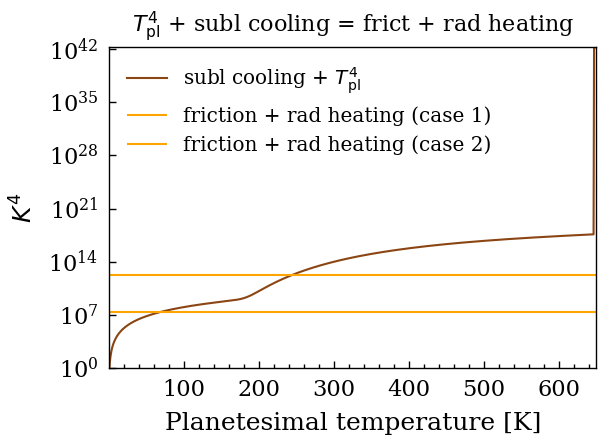

In [13]:
Ts = np.linspace(1, 650, 1000)

plt.plot(Ts, T_pl_dependent_terms(Ts), label=r'subl cooling + $T_\mathrm{pl}^4$', c='saddlebrown')
plt.hlines(T_pl_independent_terms(three_pl_results['min_periastron'], three_pl_results['min_semimajor'], r_pls[1]).value, Ts[0], Ts[-1], label='friction + rad heating (case 1)', color='orange')
plt.hlines(T_pl_independent_terms(three_pl_results['all_peris'][3], three_pl_results['all_semis'][3], r_pls[1]).value, Ts[0], Ts[-1], label='friction + rad heating (case 2)', color='orange')
#plt.plot(Ts, Ts**4, label=r'$T_\mathrm{pl}^4$', c='steelblue', linestyle='--')
# for i in range(400):
#     plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[-i]), c='orange', alpha=0.5)
#     #plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[-i]), c='orange')
#     if i == 0:
#         plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[i]), label=f'T_pl independent terms', c='orange')
#plt.ylim(1e0, 1e26)
plt.yscale('log')
plt.xlabel('Planetesimal temperature [K]')
plt.ylabel(r'$K^4$')
#plt.grid()
plt.legend(loc='upper left')
plt.title(r'$T_\mathrm{pl}^4$ + subl cooling = frict + rad heating', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
from scipy.optimize import brentq

def solve_for_T_pl(peri, semi, r_pl, T_range = (1, 800)):

    ind = T_pl_independent_terms(peri, semi, r_pl)
    def diff(T):
        return T_pl_dependent_terms(T).value - ind.value
    
    T_solution = brentq(diff, T_range[0], T_range[1])
    return T_solution


T_solutions = [solve_for_T_pl(three_pl_results['all_peris'][3], three_pl_results['all_semis'][3], r_pl) for r_pl in r_pls]

print("T_pl solutions:", T_solutions)

T_pl solutions: [86.70858116834437, 66.95780512076091, 60.51219141280756]


## Reproduce Fig. D.1 from Eriksson 2021 - ablation rate vs semimajor axis 

In [15]:
print(r_pls)

def ablation_rate(r_pl, T_pl):
    mu_water = 18 * u.g/u.mol
    R_g = 8.314 * u.J / (u.mol * u.K)
    T_pl = T_pl * u.K
    mass_ablation = -4 * np.pi * (r_pl*u.km)**2 * P_sat_vap(T_pl) * np.sqrt(mu_water / (2*np.pi*R_g*T_pl))
    
    return mass_ablation.to('kg/yr')

print(ablation_rate(r_pls[1], 400))

[  1  10 100]
-9.04618211109649e+18 kg / yr


In [16]:
def ablation_vs_semimajor_axis(peris, semis, r_pl, factor=1, paper_method=True, paper_temp_profile=True):

    ablation_rates = []
   
    #T_solution = solve_for_T_pl(p, a, r_pl)
    if paper_method:
        for a in semis:
            #T = 150 * (a)**(-3/7)
            if paper_temp_profile:
                T = 150 * (a)**(-3/7)
            else:
                T = 38*(a/(40))**(-0.24) #new temperature profile from pds 70 modelling papers
            dm_dt = ablation_rate(r_pl, T*factor)
            ablation_rates.append(-dm_dt.value)

    else:
        for p, a in zip(peris, semis):
            T = solve_for_T_pl(p, a, r_pl)
            dm_dt = ablation_rate(r_pl, T*factor)
            ablation_rates.append(-dm_dt.value)

    ablation_rates = np.array(ablation_rates)

    return ablation_rates*u.kg/u.yr



### mass from radius of planetesimal

In [17]:
def mass_from_radius(radius):
    return 1000 * u.kg / u.m**3 * ((radius*u.km).to(u.AU))**3 * 2/3 * np.pi

print(mass_from_radius(100).to('kg'))

2.094395102393195e+18 kg


In [18]:
ablation_rates_from_data_three_pl_1km = ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False)
ablation_rates_from_data_three_pl_10km = ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[1], factor=1, paper_method=False)
ablation_rates_from_data_three_pl_100km = ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[2], factor=1, paper_method=False)


In [19]:
print(len(ablation_rates_from_data_three_pl_1km))

611


In [20]:
ablation_rates_from_data_two_pl_1km = ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False)
ablation_rates_from_data_two_pl_10km = ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[1], factor=1, paper_method=False)
ablation_rates_from_data_two_pl_100km = ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[2], factor=1, paper_method=False)


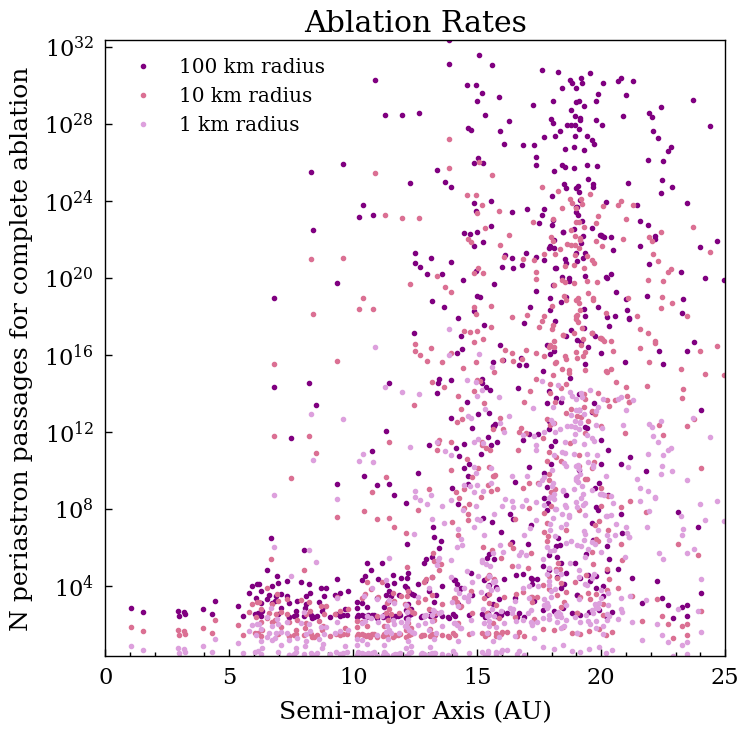

In [21]:
mass_ablated_per_passage_data_three_pl_1km = ablation_rates_from_data_three_pl_1km * time_spend_at_peri
mass_ablated_per_passage_data_three_pl_10km = ablation_rates_from_data_three_pl_10km * time_spend_at_peri
mass_ablated_per_passage_data_three_pl_100km = ablation_rates_from_data_three_pl_100km * time_spend_at_peri

number_of_passages_needed_1km = (mass_from_radius(r_pls[0]) / mass_ablated_per_passage_data_three_pl_1km).to('')
number_of_passages_needed_10km = (mass_from_radius(r_pls[1]) / mass_ablated_per_passage_data_three_pl_10km).to('')
number_of_passages_needed_100km = (mass_from_radius(r_pls[2]) / mass_ablated_per_passage_data_three_pl_100km).to('')

fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(three_pl_results['all_semis'][:], number_of_passages_needed_100km, 'o', markersize=3, c='purple', label='100 km radius')
plt.plot(three_pl_results['all_semis'][:], number_of_passages_needed_10km, 'o', markersize=3, c='palevioletred', label='10 km radius')
plt.plot(three_pl_results['all_semis'][:], number_of_passages_needed_1km, 'o', markersize=3, c='plum', label='1 km radius')

plt.xlabel('Semi-major Axis (AU)')
plt.ylabel('N periastron passages for complete ablation')
plt.title('Ablation Rates')
plt.xlim(0, 25)
plt.yscale('log')
plt.legend(loc='upper left')
#plt.ylim(1, 1e8)
#plt.yscale('log')
plt.show()


In [22]:
print(np.argmax(two_pl_results['all_semis']))
print(two_pl_results['all_peris'][128])

725
4.067829626283435


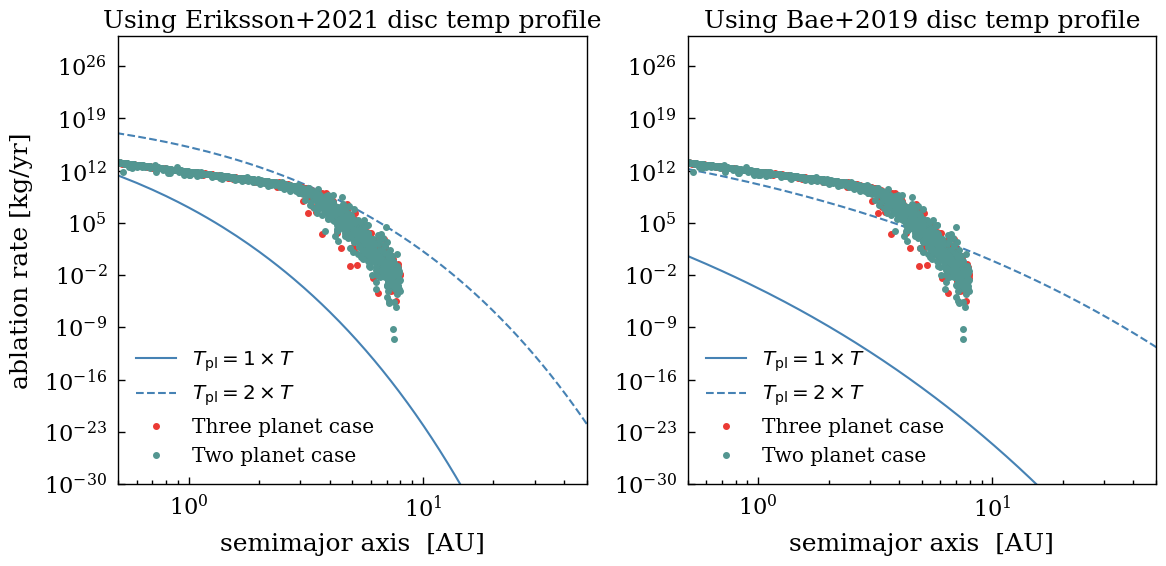

In [23]:
semis = np.linspace(0.1, 100, 1000)
fig, ax = plt.subplots(1, 2, figsize=(12,6))
# ax[0].plot(three_pl_results['all_semis'][:],
#            ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[0], factor=2, paper_method=True),
#            'o', markersize=4, label='Three planet case')
# ax[1].plot(two_pl_results['all_semis'][:],
#            ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False),
#            'o', markersize=4, label='Two planet case')

ax[0].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=1), c='steelblue', label=r'$T_\mathrm{pl} = 1 \times T$')
ax[0].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=2), linestyle='--', c='steelblue', label=r'$T_\mathrm{pl} = 2 \times T$')

ax[1].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=1, paper_temp_profile=False), c='steelblue', label=r'$T_\mathrm{pl} = 1 \times T$')
ax[1].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=2, paper_temp_profile=False), linestyle='--', c='steelblue', label=r'$T_\mathrm{pl} = 2 \times T$')


ax[0].set_ylabel('ablation rate [kg/yr]')
ax[0].set_title('Using Eriksson+2021 disc temp profile', fontsize=18)
ax[1].set_title('Using Bae+2019 disc temp profile', fontsize=18)
# ax[0].set_ylim(1, 1e25)
for i in range(2):
    ax[i].plot(three_pl_results['all_peris'][:],
           ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False),
           'o', markersize=4, label='Three planet case')
    ax[i].plot(two_pl_results['all_peris'][:],
           ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False),
           'o', markersize=4, label='Two planet case')

    ax[i].legend(loc='lower left')
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
    ax[i].set_xlabel('semimajor axis  [AU]')
    ax[i].set_xlim(0.5, 50)
    ax[i].set_ylim(1e-30, 1e30)
    
# ax[0].set_ylim(1, 1e25)
# ax[1].set_ylim(1e-5, 1e17)
#ax[0].set_xlim(1, 800)
plt.tight_layout()
plt.show()

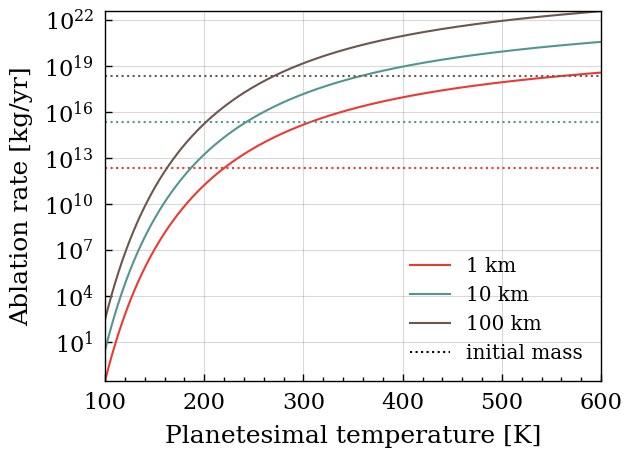

In [24]:
new_Ts = np.linspace(100, 600, 1000)

for i in range(3):
    line, = plt.plot(new_Ts, -ablation_rate(r_pls[i], new_Ts).to('kg/yr').value,
        label=f'{(r_pls[i]):.0f} km'
    )

    color = line.get_color()

    plt.hlines(mass_from_radius(r_pls[i]).to('kg').value, new_Ts[0], new_Ts[-1], linestyle=':',
               color=color)

from matplotlib.lines import Line2D

custom_line = Line2D(
    [0], [0],
    color='black',
    linestyle=':',
    label='initial mass'
)

plt.legend(handles=plt.gca().get_legend_handles_labels()[0] + [custom_line],
           labels=plt.gca().get_legend_handles_labels()[1] + ['initial mass'])

plt.yscale('log')
plt.ylabel('Ablation rate [kg/yr]')
plt.xlabel('Planetesimal temperature [K]')
plt.grid(alpha=0.3)
plt.show()

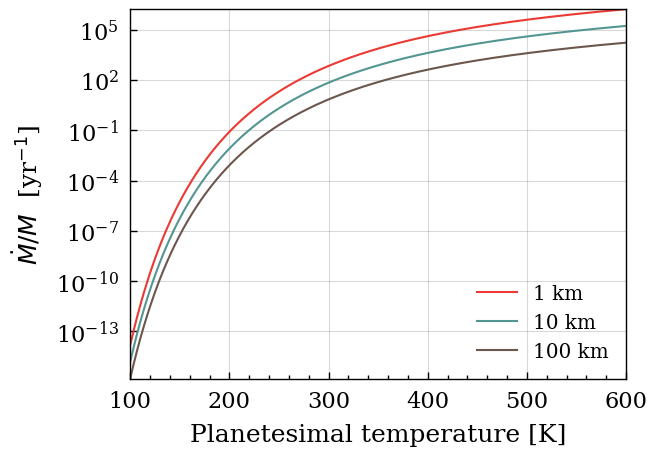

In [25]:
new_Ts = np.linspace(100, 600, 1000)

taus = [-ablation_rate(r_pls[i], new_Ts).to('kg/yr').value/mass_from_radius(r_pls[i]).to('kg').value for i in range(3)]
for i in range(3):
    tau = -ablation_rate(r_pls[i], new_Ts).to('kg/yr').value/mass_from_radius(r_pls[i]).to('kg').value
    line, = plt.plot(new_Ts, tau,
        label=f'{(r_pls[i]):.0f} km'
    )

    color = line.get_color()

from matplotlib.lines import Line2D


plt.legend()

plt.yscale('log')
plt.ylabel(r'$\dot{M}/M$  [yr$^{-1}$]')
plt.xlabel('Planetesimal temperature [K]')
plt.grid(alpha=0.3)
plt.show()

In [26]:
m = 1000 * u.kg / u.m**3 * (100 * u.km)**3 * 2/3 * np.pi
print(f'{m.to('kg'):.2e}')

2.09e+18 kg


# Method 2 - from orbits of star-grazers

# When is C_D term in min_function (stopping time) relevant?

basically we need low v_rel_mag and high speed of sound (aka temp). But more importantly, high v_rel_mag, since it only depends on T**(1/2)

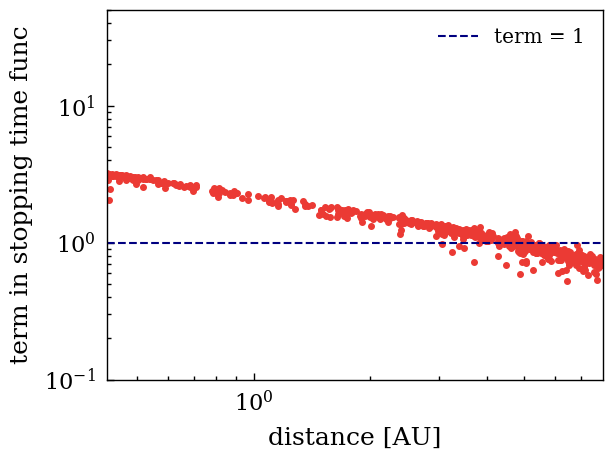

In [27]:
def C_D_term_in_min_func():

    v_K = np.sqrt(G * M_star / (peris*u.AU))

    T = 38*(peris/(40))**(-0.24) * u.K #new temperature profile from pds 70 modelling papers


    v_rel_mag = np.abs(velocities - v_K)
    c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s

    return v_rel_mag, (0.47* 3/8*v_rel_mag/(np.sqrt(8/(np.pi))*c_s_si)).to('')



# print(C_D_term_in_min_func(v_rels, 400))
# print(C_D_term_in_min_func(v_rels, 30))
plt.plot(peris, C_D_term_in_min_func()[1], 'o', markersize=4)
plt.axhline(y=1, linestyle='--', color='navy', label='term = 1')
plt.yscale('log')
plt.xscale('log')
plt.ylim(0.1, 50)
plt.legend()
plt.xlabel('distance [AU]')
plt.ylabel('term in stopping time func')
plt.show()

the answer is, it's relevant for very low relative velocities, that is, high periastrons. I don't know why there is an outlier.